In [23]:
import re
from collections import defaultdict

def extract_chemical_formula_moiety(file_path):
    with open(file_path, 'r') as file:
        cif_content = file.read()
    
    # Find the chemical formula moiety using regex
    pattern = r"_chemical_formula_moiety\s+['\";]([^;'\"]+)['\";]"
    match = re.search(pattern, cif_content)
    if not match:
        raise ValueError("Chemical formula moiety not found.")
    formula = match.group(1).strip()
    return formula

def parse_formula_with_quantity(formula: str):
    element_pattern = r"(\d*)\(?([A-Za-z0-9\s]+)\)?(\d*)(\d+[+-]?)"
    moieties_info = []

    for match in re.findall(element_pattern, formula):
        quantity = int(match[0]) if match[0] else 1
        elements = defaultdict(int)
        for element, count in re.findall(r"([A-Z][a-z]*)(\d*)", match[1]):
            elements[element] += int(count) if count else 1

        charge_str = match[3]
        charge = int(charge_str[:-1]) * (1 if charge_str.endswith("+") else -1)

        moieties_info.append({
            "elements": dict(elements),
            "quantity": quantity,
            "charge": charge
        })
    return moieties_info

# Example usage
file_path = "error_2/CSCNCC01/CSCNCC01.cif"
file_path = "error_2/APRCOB/APRCOB.cif"
chemical_formula = extract_chemical_formula_moiety(file_path)
moieties_info = parse_formula_with_quantity(chemical_formula)

# Display results
print("Chemical Formula Moiety:", chemical_formula)
print("Moieties Information:")
for i, moiety in enumerate(moieties_info, 1):
    print(f"Moiety {i}:")
    print(f"  Elements: {moiety['elements']}")
    print(f"  Quantity: {moiety['quantity']}")
    print(f"  Charge: {moiety['charge']}")


Chemical Formula Moiety: C6 H14 Co1 N4 O4 1+,Br1 1-
Moieties Information:
Moiety 1:
  Elements: {'C': 6, 'H': 14, 'Co': 1, 'N': 4, 'O': 4}
  Quantity: 1
  Charge: 1
Moiety 2:
  Elements: {'Br': 1}
  Quantity: 1
  Charge: -1


In [1]:
import ase.io
from ase.spacegroup

In [3]:
input_path= "error_4/BOFFOS/BOFFOS.cif"

In [1]:
from ase.io import read, write
from ase.spacegroup import crystal, get_spacegroup
cif_file_path = "error_2/BOFFOS/BOFFOS.cif"
xyz_file_path = "error_2/BOFFOS/Ref_All_BOFFOS.xyz"
# Load the initial structure from CIF file
initial_structure = read(cif_file_path, format='cif')

# Extract cell parameters and atomic positions from the CIF file
cell = initial_structure.cell.cellpar()
# symbols = initial_structure.get_chemical_symbols()
# positions = initial_structure.get_positions()
space_group = initial_structure.info['spacegroup']

/opt/anaconda3/envs/cell2mol/lib/python3.10/site-packages/ase/spacegroup/spacegroup.py:433: UserWarning: scaled_positions 0 and 59 are equivalent
  warnings.warn('scaled_positions %d and %d '
/opt/anaconda3/envs/cell2mol/lib/python3.10/site-packages/ase/spacegroup/spacegroup.py:433: UserWarning: scaled_positions 0 and 60 are equivalent
  warnings.warn('scaled_positions %d and %d '
/opt/anaconda3/envs/cell2mol/lib/python3.10/site-packages/ase/spacegroup/spacegroup.py:433: UserWarning: scaled_positions 2 and 61 are equivalent
  warnings.warn('scaled_positions %d and %d '
/opt/anaconda3/envs/cell2mol/lib/python3.10/site-packages/ase/spacegroup/spacegroup.py:433: UserWarning: scaled_positions 2 and 62 are equivalent
  warnings.warn('scaled_positions %d and %d '
/opt/anaconda3/envs/cell2mol/lib/python3.10/site-packages/ase/spacegroup/spacegroup.py:433: UserWarning: scaled_positions 3 and 63 are equivalent
  warnings.warn('scaled_positions %d and %d '
/opt/anaconda3/envs/cell2mol/lib/python3

In [2]:
cell

array([ 24.369,  24.369,   9.748,  90.   ,  90.   , 120.   ])

In [3]:
space_group, space_group.no, space_group.symbol

(Spacegroup(146, setting=1), 146, 'R 3')

In [4]:
# Access symmetry operations
symmetry_operations = space_group.get_symop()
for op in symmetry_operations:
    print(op)


(array([[1, 0, 0],
       [0, 1, 0],
       [0, 0, 1]]), array([0., 0., 0.]))
(array([[ 0, -1,  0],
       [ 1, -1,  0],
       [ 0,  0,  1]]), array([0., 0., 0.]))
(array([[-1,  1,  0],
       [-1,  0,  0],
       [ 0,  0,  1]]), array([0., 0., 0.]))
(array([[1, 0, 0],
       [0, 1, 0],
       [0, 0, 1]]), array([0.66666667, 0.33333333, 0.33333333]))
(array([[ 0, -1,  0],
       [ 1, -1,  0],
       [ 0,  0,  1]]), array([0.66666667, 0.33333333, 0.33333333]))
(array([[-1,  1,  0],
       [-1,  0,  0],
       [ 0,  0,  1]]), array([0.66666667, 0.33333333, 0.33333333]))
(array([[1, 0, 0],
       [0, 1, 0],
       [0, 0, 1]]), array([0.33333333, 0.66666667, 0.66666667]))
(array([[ 0, -1,  0],
       [ 1, -1,  0],
       [ 0,  0,  1]]), array([0.33333333, 0.66666667, 0.66666667]))
(array([[-1,  1,  0],
       [-1,  0,  0],
       [ 0,  0,  1]]), array([0.33333333, 0.66666667, 0.66666667]))


In [5]:
for i, (rot, trans) in enumerate(space_group.get_symop()):
    print("Symmetry operation #{}".format(i + 1))
    print("Rotation matrix: ", rot[0,:])
    print("                 ", rot[1,:])
    print("                 ", rot[2,:])
    print("Translation vector: ", trans)
    print()

Symmetry operation #1
Rotation matrix:  [1 0 0]
                  [0 1 0]
                  [0 0 1]
Translation vector:  [0. 0. 0.]

Symmetry operation #2
Rotation matrix:  [ 0 -1  0]
                  [ 1 -1  0]
                  [0 0 1]
Translation vector:  [0. 0. 0.]

Symmetry operation #3
Rotation matrix:  [-1  1  0]
                  [-1  0  0]
                  [0 0 1]
Translation vector:  [0. 0. 0.]

Symmetry operation #4
Rotation matrix:  [1 0 0]
                  [0 1 0]
                  [0 0 1]
Translation vector:  [0.66666667 0.33333333 0.33333333]

Symmetry operation #5
Rotation matrix:  [ 0 -1  0]
                  [ 1 -1  0]
                  [0 0 1]
Translation vector:  [0.66666667 0.33333333 0.33333333]

Symmetry operation #6
Rotation matrix:  [-1  1  0]
                  [-1  0  0]
                  [0 0 1]
Translation vector:  [0.66666667 0.33333333 0.33333333]

Symmetry operation #7
Rotation matrix:  [1 0 0]
                  [0 1 0]
                  [0 0 1]
Transl

In [24]:
import numpy as np
# Example lattice vectors (you should replace these with your actual lattice vectors)
a = np.array([cell[0], 0, 0])  # length of vector a in Angstroms
b = np.array([0, cell[1], 0])  # length of vector b in Angstroms
c = np.array([0, 0, cell[2]])  # length of vector c in Angstroms

# Create a matrix of lattice vectors
lattice_vectors = np.array([a, b, c]).T

In [25]:
lattice_vectors

array([[24.369,  0.   ,  0.   ],
       [ 0.   , 24.369,  0.   ],
       [ 0.   ,  0.   ,  9.748]])

In [26]:
# Convert each operation to Cartesian coordinates
sym_ops_cartesian = []
sym_ops_fractional = space_group.get_symop()
for rot_frac, trans_frac in sym_ops_fractional:
    rot_cart = lattice_vectors @ rot_frac @ np.linalg.inv(lattice_vectors)
    trans_cart = lattice_vectors @ trans_frac
    sym_ops_cartesian.append((rot_cart, trans_cart))

In [27]:
sym_ops_cartesian

[(array([[1., 0., 0.],
         [0., 1., 0.],
         [0., 0., 1.]]),
  array([0., 0., 0.])),
 (array([[ 0., -1.,  0.],
         [ 1., -1.,  0.],
         [ 0.,  0.,  1.]]),
  array([0., 0., 0.])),
 (array([[-1.,  1.,  0.],
         [-1.,  0.,  0.],
         [ 0.,  0.,  1.]]),
  array([0., 0., 0.])),
 (array([[1., 0., 0.],
         [0., 1., 0.],
         [0., 0., 1.]]),
  array([16.246     ,  8.123     ,  3.24933333])),
 (array([[ 0., -1.,  0.],
         [ 1., -1.,  0.],
         [ 0.,  0.,  1.]]),
  array([16.246     ,  8.123     ,  3.24933333])),
 (array([[-1.,  1.,  0.],
         [-1.,  0.,  0.],
         [ 0.,  0.,  1.]]),
  array([16.246     ,  8.123     ,  3.24933333])),
 (array([[1., 0., 0.],
         [0., 1., 0.],
         [0., 0., 1.]]),
  array([ 8.123     , 16.246     ,  6.49866667])),
 (array([[ 0., -1.,  0.],
         [ 1., -1.,  0.],
         [ 0.,  0.,  1.]]),
  array([ 8.123     , 16.246     ,  6.49866667])),
 (array([[-1.,  1.,  0.],
         [-1.,  0.,  0.],
        

In [46]:
labels = atoms.get_chemical_symbols(),
positions = atoms.positions

In [45]:
sym_ops_cartesian

[(array([[1., 0., 0.],
         [0., 1., 0.],
         [0., 0., 1.]]),
  array([0., 0., 0.])),
 (array([[ 0., -1.,  0.],
         [ 1., -1.,  0.],
         [ 0.,  0.,  1.]]),
  array([0., 0., 0.])),
 (array([[-1.,  1.,  0.],
         [-1.,  0.,  0.],
         [ 0.,  0.,  1.]]),
  array([0., 0., 0.])),
 (array([[1., 0., 0.],
         [0., 1., 0.],
         [0., 0., 1.]]),
  array([16.246     ,  8.123     ,  3.24933333])),
 (array([[ 0., -1.,  0.],
         [ 1., -1.,  0.],
         [ 0.,  0.,  1.]]),
  array([16.246     ,  8.123     ,  3.24933333])),
 (array([[-1.,  1.,  0.],
         [-1.,  0.,  0.],
         [ 0.,  0.,  1.]]),
  array([16.246     ,  8.123     ,  3.24933333])),
 (array([[1., 0., 0.],
         [0., 1., 0.],
         [0., 0., 1.]]),
  array([ 8.123     , 16.246     ,  6.49866667])),
 (array([[ 0., -1.,  0.],
         [ 1., -1.,  0.],
         [ 0.,  0.,  1.]]),
  array([ 8.123     , 16.246     ,  6.49866667])),
 (array([[-1.,  1.,  0.],
         [-1.,  0.,  0.],
        

In [40]:
labels

(['K',
  'Fe',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'C',
  'H',
  'H',
  'C',
  'H',
  'H',
  'C',
  'H',
  'H',
  'C',
  'H',
  'H',
  'C',
  'H',
  'H',
  'C',
  'H',
  'H',
  'C',
  'H',
  'H',
  'C',
  'H',
  'H',
  'C',
  'H',
  'H',
  'C',
  'H',
  'H',
  'C',
  'H',
  'H',
  'C',
  'H',
  'H',
  'C',
  'C',
  'H',
  'H',
  'H',
  'H',
  'H',
  'H',
  'K',
  'K',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'O',
  'C',
  'C',
  'H',
  'H',
  'H',
  'H',
  'C',
  'C',
  'H',
  'H',
  'H',
  'H',
  'C',
  'C',
  'H',
  'H',
  'H',
  'H',
  'C',
  'C',
  'H',
  'H',
  'H',
  'H',
  'C',
  'C',
  'H',
  'H',
  'H',
  'H',
  'C',
  'C',
  'H',
  'H',
  'H',
  'H',
  'C',
  'C',
  'H',
  'H',
  'H',
  'H',
  'C',
  'C',
  'H',
  'H',
  'H',
  'H',
  'C',
  'C',
  'H',
  'H',
  'H',
  'H',
  'C',
  'C',
  'H',
  'H',
  'H',
  'H',
  'C',
  'C'

In [50]:
positions

array([[14.586187, 10.49194 ,  6.840074],
       [12.185718,  7.034021,  9.395122],
       [15.035307,  9.651149,  4.231314],
       [12.463647, 10.436225,  4.932293],
       [12.009409, 11.296853,  7.554505],
       [14.172645, 12.408199,  9.007249],
       [16.712138, 11.83121 ,  8.150303],
       [17.233391, 10.873925,  5.55441 ],
       [15.732626,  8.578424,  8.425196],
       [13.601557,  7.986663,  8.331421],
       [13.773237,  6.633253, 10.549481],
       [15.920268,  7.135743, 10.792011],
       [18.384461,  8.708004,  9.464333],
       [ 8.947566, 13.331506,  4.549392],
       [18.450623,  6.839229,  2.009063],
       [13.971844,  9.667611,  3.294824],
       [14.124272,  8.994599,  2.613439],
       [13.92932 , 10.535203,  2.861038],
       [12.69698 ,  9.39389 ,  3.992781],
       [11.968834,  9.35548 ,  3.352337],
       [12.746205,  8.540859,  4.450937],
       [11.209131, 10.29947 ,  5.581705],
       [11.173186,  9.450449,  6.050584],
       [10.495728, 10.31572 ,  4.9

In [47]:
# List to collect all transformed structures and their labels
all_transformed_positions = []
all_labels = []

# Apply all symmetry operations
for rot_cart, trans_cart in sym_ops_cartesian:
    transformed_positions = (rot_cart @ positions.T + trans_cart[:, np.newaxis]).T
    all_transformed_positions.append(transformed_positions)
    all_labels.append(labels)  # Copy labels directly since symmetry operations don't alter the type of atoms



In [60]:
sym_ops_cartesian

[(array([[1., 0., 0.],
         [0., 1., 0.],
         [0., 0., 1.]]),
  array([0., 0., 0.])),
 (array([[ 0., -1.,  0.],
         [ 1., -1.,  0.],
         [ 0.,  0.,  1.]]),
  array([0., 0., 0.])),
 (array([[-1.,  1.,  0.],
         [-1.,  0.,  0.],
         [ 0.,  0.,  1.]]),
  array([0., 0., 0.])),
 (array([[1., 0., 0.],
         [0., 1., 0.],
         [0., 0., 1.]]),
  array([16.246     ,  8.123     ,  3.24933333])),
 (array([[ 0., -1.,  0.],
         [ 1., -1.,  0.],
         [ 0.,  0.,  1.]]),
  array([16.246     ,  8.123     ,  3.24933333])),
 (array([[-1.,  1.,  0.],
         [-1.,  0.,  0.],
         [ 0.,  0.,  1.]]),
  array([16.246     ,  8.123     ,  3.24933333])),
 (array([[1., 0., 0.],
         [0., 1., 0.],
         [0., 0., 1.]]),
  array([ 8.123     , 16.246     ,  6.49866667])),
 (array([[ 0., -1.,  0.],
         [ 1., -1.,  0.],
         [ 0.,  0.,  1.]]),
  array([ 8.123     , 16.246     ,  6.49866667])),
 (array([[-1.,  1.,  0.],
         [-1.,  0.,  0.],
        

In [48]:
len(all_labels)

9

In [55]:
from cell2mol.read_write import writexyz

In [56]:
import os

In [58]:
os.

AttributeError: module 'os' has no attribute 'getpwd'

In [59]:
for idx, (lab, pos) in enumerate(zip(all_labels, all_transformed_positions)):
    writexyz("error_2/BOFFOS", f"BOFFOS_symmetry_operation_{idx}.xyz", lab[0], pos)
    print(lab[0])
    print(pos)

['K', 'Fe', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'C', 'H', 'H', 'C', 'H', 'H', 'C', 'H', 'H', 'C', 'H', 'H', 'C', 'H', 'H', 'C', 'H', 'H', 'C', 'H', 'H', 'C', 'H', 'H', 'C', 'H', 'H', 'C', 'H', 'H', 'C', 'H', 'H', 'C', 'H', 'H', 'C', 'C', 'H', 'H', 'H', 'H', 'H', 'H', 'K', 'K', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'C', 'C', 'H', 'H', 'H', 'H', 'C', 'C', 'H', 'H', 'H', 'H', 'C', 'C', 'H', 'H', 'H', 'H', 'C', 'C', 'H', 'H', 'H', 'H', 'C', 'C', 'H', 'H', 'H', 'H', 'C', 'C', 'H', 'H', 'H', 'H', 'C', 'C', 'H', 'H', 'H', 'H', 'C', 'C', 'H', 'H', 'H', 'H', 'C', 'C', 'H', 'H', 'H', 'H', 'C', 'C', 'H', 'H', 'H', 'H', 'C', 'C', 'H', 'H', 'H', 'H', 'C', 'C', 'H', 'H', 'H', 'H', 'C', 'C', 'C', 'C']
[[14.586187 10.49194   6.840074]
 [12.185718  7.034021  9.395122]
 [15.035307  9.651149  4.231314]
 [12.463647 10.436225  4.932293]
 [12.009409 11.296853  7.554505]
 [14.172645 12.408199  9.007249]
 [16.712138 11.

In [49]:
len(all_transformed_positions)

9

In [29]:
transformed_positions

array([[ 5.,  5.,  5.],
       [ 5.,  5., 15.]])

<Axes: >

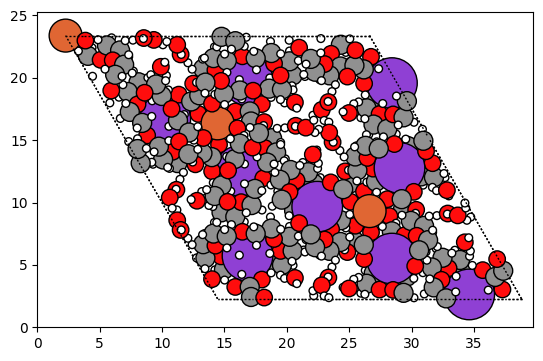

In [7]:
import matplotlib.pyplot as plt
from ase.visualize.plot import plot_atoms
plot_atoms(initial_structure)

Cell([0.0, 0.0, 0.0])

In [12]:
atoms.get_scaled_positions()

array([[14.586187, 10.49194 ,  6.840074],
       [12.185718,  7.034021,  9.395122],
       [15.035307,  9.651149,  4.231314],
       [12.463647, 10.436225,  4.932293],
       [12.009409, 11.296853,  7.554505],
       [14.172645, 12.408199,  9.007249],
       [16.712138, 11.83121 ,  8.150303],
       [17.233391, 10.873925,  5.55441 ],
       [15.732626,  8.578424,  8.425196],
       [13.601557,  7.986663,  8.331421],
       [13.773237,  6.633253, 10.549481],
       [15.920268,  7.135743, 10.792011],
       [18.384461,  8.708004,  9.464333],
       [ 8.947566, 13.331506,  4.549392],
       [18.450623,  6.839229,  2.009063],
       [13.971844,  9.667611,  3.294824],
       [14.124272,  8.994599,  2.613439],
       [13.92932 , 10.535203,  2.861038],
       [12.69698 ,  9.39389 ,  3.992781],
       [11.968834,  9.35548 ,  3.352337],
       [12.746205,  8.540859,  4.450937],
       [11.209131, 10.29947 ,  5.581705],
       [11.173186,  9.450449,  6.050584],
       [10.495728, 10.31572 ,  4.9

In [20]:
# Load your initial atomic positions; assuming these are stored in an XYZ file
atoms = read(xyz_file_path, format='xyz')

# Create the crystal structure using the symmetry of the space group
crystal_structure = crystal(symbols=atoms.get_chemical_symbols(),
                            basis=atoms.get_positions(),
                            spacegroup=space_group,
                            cellpar=cell)

# # # Save the complete structure to a new XYZ file
# cell_xyz_file_path = "error_2/BOFFOS/BOFFOS_complete_structure.xyz"
# write(cell_xyz_file_path, crystal_structure, format='xyz')

# print(f"XYZ file with complete structure saved as {xyz_file_path}")

<Axes: >

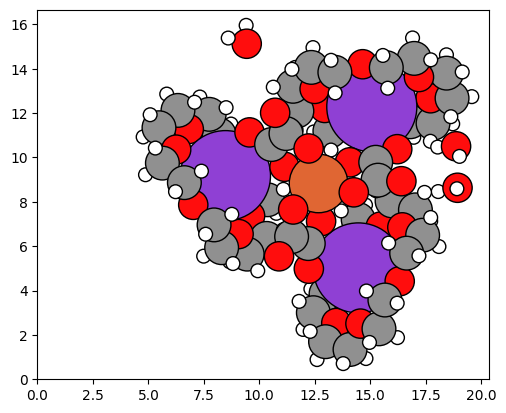

In [18]:
plot_atoms(atoms)

<Axes: >

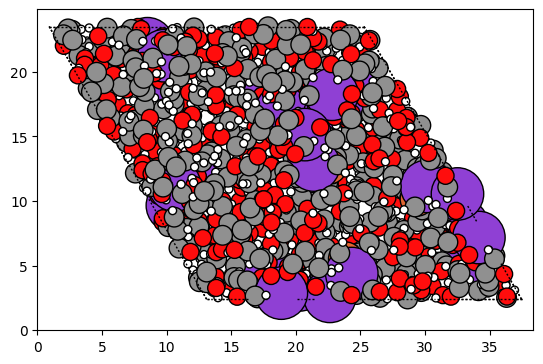

In [21]:
plot_atoms(crystal_structure)

In [10]:
from ase.visualize import view


In [11]:
view(atoms)

<Popen: returncode: None args: ['/opt/anaconda3/envs/cell2mol/bin/python', '...>

In [34]:
len(atoms)

157

In [32]:
atoms.get_positions()

array([[14.586187, 10.49194 ,  6.840074],
       [12.185718,  7.034021,  9.395122],
       [15.035307,  9.651149,  4.231314],
       [12.463647, 10.436225,  4.932293],
       [12.009409, 11.296853,  7.554505],
       [14.172645, 12.408199,  9.007249],
       [16.712138, 11.83121 ,  8.150303],
       [17.233391, 10.873925,  5.55441 ],
       [15.732626,  8.578424,  8.425196],
       [13.601557,  7.986663,  8.331421],
       [13.773237,  6.633253, 10.549481],
       [15.920268,  7.135743, 10.792011],
       [18.384461,  8.708004,  9.464333],
       [ 8.947566, 13.331506,  4.549392],
       [18.450623,  6.839229,  2.009063],
       [13.971844,  9.667611,  3.294824],
       [14.124272,  8.994599,  2.613439],
       [13.92932 , 10.535203,  2.861038],
       [12.69698 ,  9.39389 ,  3.992781],
       [11.968834,  9.35548 ,  3.352337],
       [12.746205,  8.540859,  4.450937],
       [11.209131, 10.29947 ,  5.581705],
       [11.173186,  9.450449,  6.050584],
       [10.495728, 10.31572 ,  4.9

In [ ]:
from ase import Atoms
from ase.io import read, write
from ase.spacegroup import crystal

# Define the unit cell parameters
a = 24.369  # Lattice constant a
c = 9.748   # Lattice constant c
cell = [a, a, c, 90, 90, 120]  # Rhombohedral cell parameters
spacegroup = 'R3'  # Space group 'R 3'

# Load your initial atomic positions; assuming these are stored in an XYZ file
atoms = read('path_to_your_file.xyz', format='xyz')

# Create the crystal structure using the symmetry of the space group
crystal_structure = crystal(symbols=atoms.get_chemical_symbols(),
                            basis=atoms.get_positions(),
                            spacegroup=spacegroup,
                            cellpar=cell)

# Save the complete structure to a new XYZ file
xyz_file_path = 'complete_structure.xyz'
write(xyz_file_path, crystal_structure, format='xyz')

print(f"XYZ file with complete structure saved as {xyz_file_path}")


In [4]:
help(ase.io.read)

Help on function read in module ase.io.formats:

read(filename: Union[str, pathlib.PurePath, IO], index: Any = None, format: str = None, parallel: bool = True, do_not_split_by_at_sign: bool = False, **kwargs) -> Union[ase.atoms.Atoms, List[ase.atoms.Atoms]]
    Read Atoms object(s) from file.
    
    filename: str or file
        Name of the file to read from or a file descriptor.
    index: int, slice or str
        The last configuration will be returned by default.  Examples:
    
            * ``index=0``: first configuration
            * ``index=-2``: second to last
            * ``index=':'`` or ``index=slice(None)``: all
            * ``index='-3:'`` or ``index=slice(-3, None)``: three last
            * ``index='::2'`` or ``index=slice(0, None, 2)``: even
            * ``index='1::2'`` or ``index=slice(1, None, 2)``: odd
    format: str
        Used to specify the file-format.  If not given, the
        file-format will be guessed by the *filetype* function.
    parallel: boo

In [5]:
atoms = ase.io.read(input_path)

/opt/anaconda3/envs/cell2mol/lib/python3.10/site-packages/ase/spacegroup/spacegroup.py:433: UserWarning: scaled_positions 0 and 59 are equivalent
  warnings.warn('scaled_positions %d and %d '
/opt/anaconda3/envs/cell2mol/lib/python3.10/site-packages/ase/spacegroup/spacegroup.py:433: UserWarning: scaled_positions 0 and 60 are equivalent
  warnings.warn('scaled_positions %d and %d '
/opt/anaconda3/envs/cell2mol/lib/python3.10/site-packages/ase/spacegroup/spacegroup.py:433: UserWarning: scaled_positions 2 and 61 are equivalent
  warnings.warn('scaled_positions %d and %d '
/opt/anaconda3/envs/cell2mol/lib/python3.10/site-packages/ase/spacegroup/spacegroup.py:433: UserWarning: scaled_positions 2 and 62 are equivalent
  warnings.warn('scaled_positions %d and %d '
/opt/anaconda3/envs/cell2mol/lib/python3.10/site-packages/ase/spacegroup/spacegroup.py:433: UserWarning: scaled_positions 3 and 63 are equivalent
  warnings.warn('scaled_positions %d and %d '
/opt/anaconda3/envs/cell2mol/lib/python3

In [6]:
atoms[0]

Atom('K', [14.586186795000003, 10.49193963917675, 6.84007412], index=0)

In [7]:
atoms[59]

Atom('O', [12.984899805, 0.7426558501511199, 5.554410399999999], index=59)

In [11]:
atoms._get_cell()

AttributeError: 'Atoms' object has no attribute '_get_cell'

In [ ]:
import ase.structure


ase.structur

In [9]:
import ase.spacegroup


help(ase.spacegroup)

Help on package ase.spacegroup in ase:

NAME
    ase.spacegroup

PACKAGE CONTENTS
    crystal_data
    spacegroup
    symmetrize
    utils
    xtal

CLASSES
    builtins.object
        ase.spacegroup.spacegroup.Spacegroup
    
    class Spacegroup(builtins.object)
     |  Spacegroup(spacegroup: Union[int, str, ForwardRef('Spacegroup')], setting=1, datafile=None)
     |  
     |  A space group class.
     |  
     |  The instances of Spacegroup describes the symmetry operations for
     |  the given space group.
     |  
     |  Example:
     |  
     |  >>> from ase.spacegroup import Spacegroup
     |  >>>
     |  >>> sg = Spacegroup(225)
     |  >>> print('Space group', sg.no, sg.symbol)
     |  Space group 225 F m -3 m
     |  >>> sg.scaled_primitive_cell
     |  array([[ 0. ,  0.5,  0.5],
     |         [ 0.5,  0. ,  0.5],
     |         [ 0.5,  0.5,  0. ]])
     |  >>> sites, kinds = sg.equivalent_sites([[0,0,0]])
     |  >>> sites
     |  array([[ 0. ,  0. ,  0. ],
     |         

In [ ]:
from ase.io import read, write
from ase.spacegroup import crystal

# Path to your CIF file
cif_file_path = 'path_to_your_cif_file.cif'

# Load the initial structure from CIF file
initial_structure = read(cif_file_path, format='cif')

# Extract cell parameters and atomic positions from the CIF file
cell = initial_structure.cell.cellpar()
symbols = initial_structure.get_chemical_symbols()
positions = initial_structure.get_positions()
spacegroup = 'R3'  # Space group 'R 3', make sure it matches the CIF space group if different

# Create the crystal structure using the symmetry of the space group
crystal_structure = crystal(symbols=symbols,
                            basis=positions,
                            spacegroup=spacegroup,
                            cellpar=cell)

# Save the complete structure to an XYZ file
xyz_file_path = 'complete_structure.xyz'
write(xyz_file_path, crystal_structure, format='xyz')

print(f"XYZ file with complete structure saved as {xyz_file_path}")


In [1]:
import numpy as np
import gemmi

In [3]:
import numpy as np
import gemmi
import re

def clean_number(string):
    # Remove uncertainty parentheses
    return re.sub(r'\(.*\)', '', string)

def read_cif(cif_path):
    doc = gemmi.cif.read_file(cif_path)
    block = doc.sole_block()

    # Extract unit cell parameters with uncertainties removed
    cell = gemmi.UnitCell(
        float(clean_number(block.find_value('_cell_length_a'))),
        float(clean_number(block.find_value('_cell_length_b'))),
        float(clean_number(block.find_value('_cell_length_c'))),
        float(clean_number(block.find_value('_cell_angle_alpha'))),
        float(clean_number(block.find_value('_cell_angle_beta'))),
        float(clean_number(block.find_value('_cell_angle_gamma')))
    )

    # Extract symmetry operations
    symmetry_ops = []
    sym_loop = block.find_loop('_symmetry_equiv_pos_as_xyz')
    for op in sym_loop:
        symmetry_ops.append(op)

    return cell, symmetry_ops

def convert_symmetry_to_cartesian(cell, symmetry_ops):
    # Create transformation matrix from fractional to Cartesian
    to_cartesian = np.array(cell.orthogonalization_matrix).reshape(3, 3)
    to_fractional = np.linalg.inv(to_cartesian)

    cartesian_ops = []
    for op in symmetry_ops:
        # Parse the operation using gemmi
        mat, vec = gemmi.cif.parse_symop(op)
        rot_matrix_frac = np.array(mat.mat).reshape(3, 3)
        trans_vector_frac = np.array(vec)

        # Convert rotation and translation to Cartesian
        rot_matrix_cart = np.dot(to_cartesian, np.dot(rot_matrix_frac, to_fractional))
        trans_vector_cart = np.dot(to_cartesian, trans_vector_frac)

        cartesian_ops.append((rot_matrix_cart, trans_vector_cart))

    return cartesian_ops

# Path to the CIF file
cif_path = "error_2/BOFFOS/BOFFOS.cif"

# Process the CIF file
cell, symmetry_ops = read_cif(cif_path)
cartesian_ops = convert_symmetry_to_cartesian(cell, symmetry_ops)

# Print the converted Cartesian symmetry operations
for i, op in enumerate(cartesian_ops, 1):
    print(f"Operation {i}: Rotation Matrix\n{op[0]}\nTranslation Vector\n{op[1]}\n")


AttributeError: module 'gemmi.cif' has no attribute 'parse_symop'

In [ ]:
gemmi